### Libs & Preprocessing

In [184]:
import ast
import json
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [185]:
d1 = pd.read_excel('/kaggle/input/datasets/omarahmedmohamed2005/hackamacka/DeepX_train.xlsx')
d1.head()

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [186]:
d1.tail()

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
1966,6530,بصراحه كنت بحبو جدا جدا والناس كانت محترمه بس ...,1,2026-03-10 00:00:00,Careem,transport,play_store,"[""service"", ""delivery"", ""price"", ""app_experien...","{""service"": ""positive"", ""delivery"": ""negative""..."
1967,4612,المطعم قعدته حلوه وفى زحليقه ومرجيحه للاطفال\n...,3,قبل 3 أشهر,Samakmak Restaurant - 6th of October Branch,مطعم مأكولات بحرية,google_maps,"[""ambiance"", ""food"", ""price"", ""service""]","{""ambiance"": ""positive"", ""food"": ""neutral"", ""p..."
1968,4769,The worst experience at the HUB. Place is dirt...,1,قبل سنتين,ال ديفينو بيتزيريا,مطعم بيتزا,google_maps,"[""cleanliness"", ""food""]","{""cleanliness"": ""negative"", ""food"": ""negative""}"
1969,5366,الكوفي في فندق الهيلتون رمسيس...\n\nتم اضافه س...,1,قبل 4 سنوات,جاردن كورت كافيه,مقهى,google_maps,"[""service""]","{""service"": ""negative""}"
1970,3691,الشغل كتير حلو ونظيف والاستقبال جميل جدا وهي ك...,5,قبل شهر,كوافير ندى,صالون تجميل,google_maps,"[""cleanliness"", ""service""]","{""cleanliness"": ""positive"", ""service"": ""positi..."


In [187]:
d2 = pd.read_excel('/kaggle/input/datasets/omarahmedmohamed2005/hackamacka/DeepX_validation.xlsx')
d2.head()

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,4446,مريم سوتلي الاظافررر تحفههه اوييي ❤️❤️❤️❤️❤️,5,قبل شهرين,Sand salon,صالون تجميل,google_maps,"[""service""]","{""service"": ""positive""}"
1,8612,التطبيق جميل .. أتمنى إضافة البحث عن طريق الخر...,4,2020-10-28 00:00:00,Aqarmap,real_estate,play_store,"[""app_experience""]","{""app_experience"": ""neutral""}"
2,6729,سراقين مكتوب وصلت السياره والسواق مارضى يقول و...,1,2026-02-04 00:00:00,Careem,transport,play_store,"[""service"", ""delivery"", ""price""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,6292,سي جيدا,1,2025-08-07 00:00:00,Elmenus,food_delivery,play_store,"[""general""]","{""general"": ""negative""}"
4,1639,مكان ممتاز جدا و الخدمة جيده جدا,4,قبل أسبوع,Holm Cafe,مقهى,google_maps,"[""ambiance"", ""service""]","{""ambiance"": ""positive"", ""service"": ""positive""}"


In [188]:
len(d1)

1971

In [189]:
len(d2)

500

In [190]:
df = pd.concat([d1, d2], ignore_index=True)

In [191]:
print(len(d1), '+', len(d2), '=', len(df))

1971 + 500 = 2471


In [192]:
df.head()

,review_id,review_text,star_rating,date,business_name,business_category,platform,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,2026-03-08 00:00:00,Noon,ecommerce,play_store,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,قبل يومين (2),ممشي مصر Mawlana Cafe,كافيه,google_maps,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,قبل شهر,بيت لحم Beet Lahm,مطعم,google_maps,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,قبل شهر,ذا بلكون كافيه الشيخ زايد,مطعم مأكولات ومشروبات,google_maps,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,قبل سنة,The Best Restaurant,مطعم,google_maps,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   review_id          2471 non-null   int64 
 1   review_text        2471 non-null   object
 2   star_rating        2471 non-null   int64 
 3   date               2471 non-null   object
 4   business_name      2471 non-null   object
 5   business_category  2471 non-null   object
 6   platform           2471 non-null   object
 7   aspects            2471 non-null   object
 8   aspect_sentiments  2471 non-null   object
dtypes: int64(2), object(7)
memory usage: 173.9+ KB


In [194]:
df.isna().sum()

review_id            0
review_text          0
star_rating          0
date                 0
business_name        0
business_category    0
platform             0
aspects              0
aspect_sentiments    0
dtype: int64

In [195]:
df.duplicated().sum()

np.int64(0)

In [196]:
df.drop_duplicates(inplace=True)
df.drop(['date', 'business_name', 'platform'], axis=1, inplace=True)
df.head()

,review_id,review_text,star_rating,business_category,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,ecommerce,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,كافيه,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,مطعم,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,مطعم مأكولات ومشروبات,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا\nالاحجام تحفة\nبالنسبه للسعر فا...,4,مطعم,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [197]:
def preprocess_for_transformer(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)           
    text = re.sub(r'http\S+|www\S+', '', text)  
    text = re.sub(r'@\w+|#\w+', '', text)       
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)  
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_text'] = df['review_text'].apply(preprocess_for_transformer)
df.head()

,review_id,review_text,star_rating,business_category,aspects,aspect_sentiments
0,7238,لا يوجد الدفع بالبطاقه عند الاستلام,3,ecommerce,"[""app_experience"", ""delivery""]","{""app_experience"": ""negative"", ""delivery"": ""ne..."
1,1036,المكان نضيف وجميل وقعدته تحفه والخدمة فوق المم...,5,كافيه,"[""cleanliness"", ""ambiance"", ""service""]","{""cleanliness"": ""positive"", ""ambiance"": ""posit..."
2,1975,تجربة سيئة سألتهم الاكل هياخد وقت قد ايه قالول...,1,مطعم,"[""service"", ""delivery"", ""food""]","{""service"": ""negative"", ""delivery"": ""negative""..."
3,3024,احلي مكان فزايد,5,مطعم مأكولات ومشروبات,"[""general""]","{""general"": ""positive""}"
4,5483,الفطير حلو جدا الاحجام تحفة بالنسبه للسعر فا ي...,4,مطعم,"[""food"", ""price""]","{""food"": ""positive"", ""price"": ""positive""}"


In [198]:
df['aspects']= df['aspects'].apply(ast.literal_eval)
df['aspect_sentiments'] = df['aspect_sentiments'].apply(ast.literal_eval)

In [199]:
from collections import Counter
all_aspects = [asp for row in df['aspects'] for asp in row]
Counter(all_aspects)

Counter({'app_experience': 573,
         'delivery': 209,
         'cleanliness': 236,
         'ambiance': 478,
         'service': 1241,
         'food': 556,
         'general': 377,
         'price': 434,
         'none': 69})

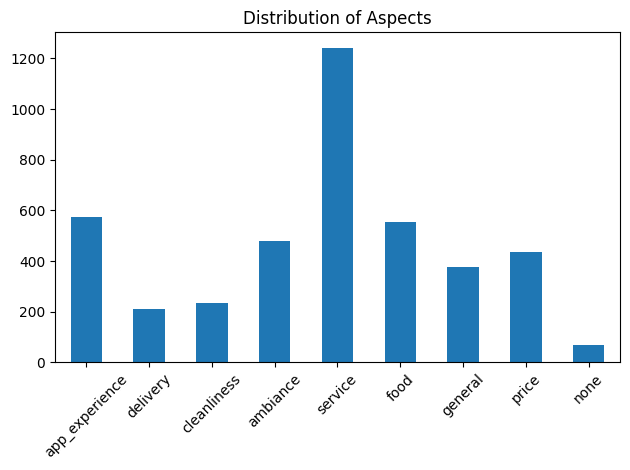

In [200]:
pd.Series(Counter(all_aspects)).plot(kind='bar')
plt.title('Distribution of Aspects')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Config & Label Encoding

In [201]:
MODEL_NAME   = 'UBC-NLP/MARBERTv2'
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 50
LR           = 2e-5
WARMUP_RATIO = 0.1
DROPOUT      = 0.3
SEED         = 42

ASPECTS = [
    'food', 'service', 'price', 'cleanliness',
    'delivery', 'ambiance', 'app_experience', 'general', 'none'
]
N_ASPECTS = len(ASPECTS)  

SENTIMENT_MAP = {'negative': 0, 'neutral': 1, 'positive': 2}
IDX2SENT      = {0: 'negative', 1: 'neutral', 2: 'positive'}
N_SENT        = 4

torch.manual_seed(SEED)
np.random.seed(SEED)

In [202]:
aspect_labels    = np.zeros((len(df), N_ASPECTS), dtype=np.float32)
sentiment_labels = np.full((len(df), N_ASPECTS), 3, dtype=np.int64)  

for i, (_, row) in enumerate(df.iterrows()):
    for asp in row['aspects']:
        if asp in ASPECTS:
            j = ASPECTS.index(asp)
            aspect_labels[i, j]    = 1.0
            sent = row['aspect_sentiments'].get(asp, 'neutral')
            sentiment_labels[i, j] = SENTIMENT_MAP[sent]

texts = df['review_text'].tolist()
print('aspect_labels shape:', aspect_labels.shape)
print('sentiment_labels shape:', sentiment_labels.shape)

aspect_labels shape: (2471, 9)
sentiment_labels shape: (2471, 9)


### Train / Val Split

In [203]:
X_train, X_val, asp_train, asp_val, sent_train, sent_val = train_test_split(
    texts, aspect_labels, sentiment_labels,
    test_size=0.15, random_state=SEED
)

print('Train:', len(X_train), '| Val:', len(X_val))

Train: 2100 | Val: 371


### Tokenizer & Dataset

In [204]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [205]:
def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN
    )

In [206]:
train_dataset = Dataset.from_dict({
    'text':       X_train,
    'asp_labels': asp_train.tolist(),
    'sent_labels': sent_train.tolist()
})

val_dataset = Dataset.from_dict({
    'text':       X_val,
    'asp_labels': asp_val.tolist(),
    'sent_labels': sent_val.tolist()
})

train_dataset = train_dataset.map(tokenize_fn, batched=True)
val_dataset   = val_dataset.map(tokenize_fn,   batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'asp_labels', 'sent_labels'])
val_dataset.set_format(  type='torch', columns=['input_ids', 'attention_mask', 'asp_labels', 'sent_labels'])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print('Train batches:', len(train_loader), '| Val batches:', len(val_loader))

Map:   0%|          | 0/2100 [00:00<?, ? examples/s]

Map:   0%|          | 0/371 [00:00<?, ? examples/s]

Train batches: 132 | Val batches: 24


### Model

In [207]:
bert           = AutoModel.from_pretrained(MODEL_NAME)
hidden         = bert.config.hidden_size  # 768

dropout        = nn.Dropout(DROPOUT)
aspect_head    = nn.Linear(hidden, N_ASPECTS)
sentiment_head = nn.Linear(hidden, N_ASPECTS * N_SENT)

bert           = bert.to(DEVICE)
aspect_head    = aspect_head.to(DEVICE)
sentiment_head = sentiment_head.to(DEVICE)

print('Model loaded. Hidden size:', hidden)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded. Hidden size: 768


In [208]:
def forward(input_ids, attention_mask):
    out  = bert(input_ids=input_ids, attention_mask=attention_mask)
    cls  = dropout(out.last_hidden_state[:, 0, :])         

    asp_logits  = aspect_head(cls)                         
    sent_logits = sentiment_head(cls).view(-1, N_ASPECTS, N_SENT)  

    return asp_logits, sent_logits

### Loss

In [209]:
asp_counts     = asp_train.sum(axis=0)
asp_pos_weight = torch.tensor(
    (len(X_train) - asp_counts) / (asp_counts + 1e-8),
    dtype=torch.float
).to(DEVICE)

asp_criterion  = nn.BCEWithLogitsLoss(pos_weight=asp_pos_weight)

sent_weights = torch.tensor([1.5, 3.0, 1.0, 0.0], dtype=torch.float).to(DEVICE)

sent_criterion = nn.CrossEntropyLoss(ignore_index=3, weight=sent_weights)

In [210]:
def compute_loss(asp_logits, sent_logits, asp_labels_b, sent_labels_b):
    loss_asp  = asp_criterion(asp_logits, asp_labels_b)

    loss_sent = sent_criterion(
        sent_logits.view(-1, N_SENT),
        sent_labels_b.view(-1)
    )

    return 0.4 * loss_asp + 0.6 * loss_sent

### Optimizer & Scheduler

In [211]:
all_params = (
    list(bert.parameters()) +
    list(aspect_head.parameters()) +
    list(sentiment_head.parameters())
)

optimizer = AdamW(all_params, lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Total steps: 6600 | Warmup steps: 660


### Training Loop

In [212]:
def train_epoch():
    bert.train()
    aspect_head.train()
    sentiment_head.train()

    total_loss = 0
    for batch in train_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        asp_labels_b   = batch['asp_labels'].to(DEVICE)
        sent_labels_b  = batch['sent_labels'].to(DEVICE)

        optimizer.zero_grad()
        asp_logits, sent_logits = forward(input_ids, attention_mask)
        loss = compute_loss(asp_logits, sent_logits, asp_labels_b, sent_labels_b)
        loss.backward()

        nn.utils.clip_grad_norm_(all_params, max_norm=1.0)

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(train_loader)

In [213]:
def eval_epoch():
    bert.eval()
    aspect_head.eval()
    sentiment_head.eval()

    total_loss = 0
    all_asp_preds, all_asp_true   = [], []
    all_sent_preds, all_sent_true = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            asp_labels_b   = batch['asp_labels'].to(DEVICE)
            sent_labels_b  = batch['sent_labels'].to(DEVICE)

            asp_logits, sent_logits = forward(input_ids, attention_mask)
            loss = compute_loss(asp_logits, sent_logits, asp_labels_b, sent_labels_b)
            total_loss += loss.item()

            asp_preds = (torch.sigmoid(asp_logits) > 0.5).long().cpu().numpy()
            all_asp_preds.append(asp_preds)
            all_asp_true.append(asp_labels_b.long().cpu().numpy())

            sent_preds = torch.argmax(sent_logits, dim=-1).cpu().numpy()  
            sent_true  = sent_labels_b.cpu().numpy()

            mask = (sent_true != 3)  
            if mask.any():
                all_sent_preds.extend(sent_preds[mask].tolist())
                all_sent_true.extend(sent_true[mask].tolist())

    all_asp_preds = np.vstack(all_asp_preds)
    all_asp_true  = np.vstack(all_asp_true)

    asp_f1  = f1_score(all_asp_true,  all_asp_preds,  average='micro', zero_division=0)
    sent_f1 = f1_score(all_sent_true, all_sent_preds, average='micro', zero_division=0) if all_sent_true else 0.0

    return total_loss / len(val_loader), asp_f1, sent_f1

Epoch 1/50
  Train Loss : 1.2467
  Val Loss   : 1.0660  |  Aspect F1: 0.3386  |  Sentiment F1: 0.6121
  ✅ Model saved  (patience reset)

Epoch 2/50
  Train Loss : 0.9629
  Val Loss   : 0.7528  |  Aspect F1: 0.4630  |  Sentiment F1: 0.8903
  ✅ Model saved  (patience reset)

Epoch 3/50
  Train Loss : 0.7263
  Val Loss   : 0.5878  |  Aspect F1: 0.5602  |  Sentiment F1: 0.9264
  ✅ Model saved  (patience reset)

Epoch 4/50
  Train Loss : 0.5831
  Val Loss   : 0.4998  |  Aspect F1: 0.6174  |  Sentiment F1: 0.9329
  ✅ Model saved  (patience reset)

Epoch 5/50
  Train Loss : 0.4726
  Val Loss   : 0.4456  |  Aspect F1: 0.6512  |  Sentiment F1: 0.9345
  ✅ Model saved  (patience reset)

Epoch 6/50
  Train Loss : 0.3972
  Val Loss   : 0.4104  |  Aspect F1: 0.7305  |  Sentiment F1: 0.9313
  ✅ Model saved  (patience reset)

Epoch 7/50
  Train Loss : 0.3213
  Val Loss   : 0.3777  |  Aspect F1: 0.7557  |  Sentiment F1: 0.9329
  ✅ Model saved  (patience reset)

Epoch 8/50
  Train Loss : 0.2698
  Val Lo

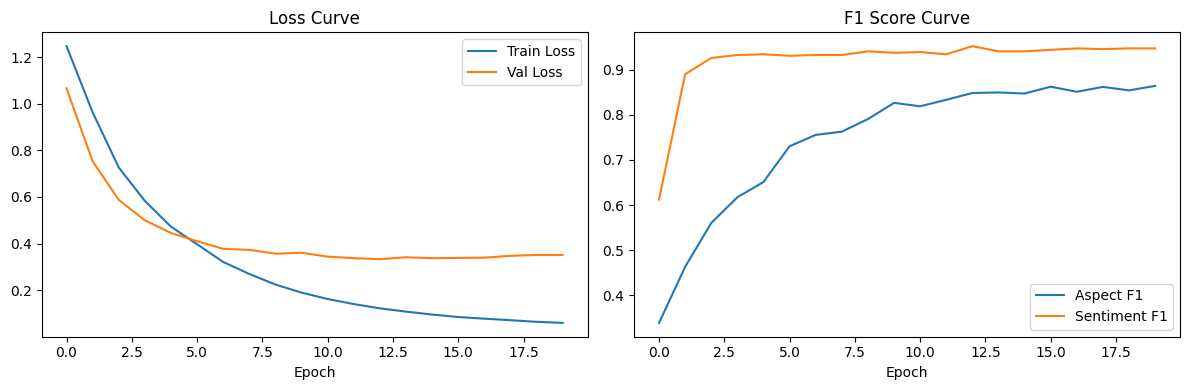

In [214]:
PATIENCE      = 7     
ES_DELTA      = 1e-4   

best_val_loss   = float('inf')
best_asp_f1     = 0.0
patience_counter = 0

history = {'train_loss': [], 'val_loss': [], 'asp_f1': [], 'sent_f1': []}

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch()
    val_loss, asp_f1, sent_f1 = eval_epoch()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['asp_f1'].append(asp_f1)
    history['sent_f1'].append(sent_f1)

    print(f'Epoch {epoch}/{EPOCHS}')
    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Val Loss   : {val_loss:.4f}  |  Aspect F1: {asp_f1:.4f}  |  Sentiment F1: {sent_f1:.4f}')

    if val_loss < best_val_loss - ES_DELTA:
        best_val_loss    = val_loss
        best_asp_f1      = asp_f1
        patience_counter = 0
        torch.save({
            'bert':           bert.state_dict(),
            'aspect_head':    aspect_head.state_dict(),
            'sentiment_head': sentiment_head.state_dict(),
            'epoch':          epoch,
            'best_val_loss':  best_val_loss,
            'best_asp_f1':    best_asp_f1,
        }, 'best_marbert_absa.pt')
        print(f'  ✅ Model saved  (patience reset)')
    else:
        patience_counter += 1
        print(f'  ⏳ No improvement  ({patience_counter}/{PATIENCE})')

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f'\n🛑 Early stopping at epoch {epoch}  —  best Val Loss: {best_val_loss:.4f}  |  best Aspect F1: {best_asp_f1:.4f}')
        break

    print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['asp_f1'],  label='Aspect F1')
ax2.plot(history['sent_f1'], label='Sentiment F1')
ax2.set_title('F1 Score Curve')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

### Load Best Model & Final Evaluation

In [215]:
checkpoint = torch.load('best_marbert_absa.pt', map_location=DEVICE)
bert.load_state_dict(checkpoint['bert'])
aspect_head.load_state_dict(checkpoint['aspect_head'])
sentiment_head.load_state_dict(checkpoint['sentiment_head'])

val_loss, asp_f1, sent_f1 = eval_epoch()
print(f'Best model  →  Aspect F1: {asp_f1:.4f}  |  Sentiment F1: {sent_f1:.4f}')

Best model  →  Aspect F1: 0.8489  |  Sentiment F1: 0.9509


### Inference

In [216]:
def predict(text, threshold=0.5):
    bert.eval()
    aspect_head.eval()
    sentiment_head.eval()

    cleaned = preprocess_for_transformer(text)
    enc = tokenizer(
        cleaned,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    with torch.no_grad():
        asp_logits, sent_logits = forward(input_ids, attention_mask)

    asp_probs  = torch.sigmoid(asp_logits).squeeze().cpu().numpy()          # (9,)
    sent_preds = torch.argmax(sent_logits, dim=-1).squeeze().cpu().numpy()  # (9,)

    detected_aspects    = []
    detected_sentiments = {}

    for j, asp in enumerate(ASPECTS):
        if asp_probs[j] >= threshold:
            detected_aspects.append(asp)
            detected_sentiments[asp] = IDX2SENT[int(sent_preds[j])]

    if not detected_aspects:
        detected_aspects    = ['none']
        detected_sentiments = {'none': 'neutral'}

    return {
        'aspects':           detected_aspects,
        'aspect_sentiments': detected_sentiments
    }

In [217]:
test_reviews = [
    'الاكل كان حلو جدا بس الخدمة كانت بطيئة والسعر غالي',
    'التطبيق بيتعلق كتير وخدمة العملاء مش بترد',
    'مكان نظيف وجو حلو وفريق محترم'
]

for rev in test_reviews:
    result = predict(rev, threshold=0.6)
    print(f'Review   : {rev}')
    print(f'Result   : {json.dumps(result, ensure_ascii=False)}')

Review   : الاكل كان حلو جدا بس الخدمة كانت بطيئة والسعر غالي
Result   : {"aspects": ["food", "service", "price", "delivery"], "aspect_sentiments": {"food": "positive", "service": "negative", "price": "negative", "delivery": "negative"}}
Review   : التطبيق بيتعلق كتير وخدمة العملاء مش بترد
Result   : {"aspects": ["app_experience"], "aspect_sentiments": {"app_experience": "negative"}}
Review   : مكان نظيف وجو حلو وفريق محترم
Result   : {"aspects": ["service", "cleanliness", "ambiance"], "aspect_sentiments": {"service": "positive", "cleanliness": "positive", "ambiance": "positive"}}


### Generate Submission File

In [247]:
test_df = pd.read_excel('/kaggle/input/datasets/omarahmedmohamed2005/hackathon/DeepX_hidden_test.xlsx')


In [248]:
test_df.head()

,review_id,review_text,star_rating,date,business_name,business_category,platform
0,23,جئت خصيصا لتجربه طبق طاجن الملوخيه باللحم مع ص...,3,قبل 3 أيام,مطعم صبحي كابر,مطعم مأكولات مصرية,google_maps
1,25,أسوأ مطعم\nطلبت منه اوردر من الساعة 2 المفروض ...,1,قبل 5 أيام,مطعم صبحي كابر,مطعم مأكولات مصرية,google_maps
2,65,المكان جميل وفيه كوفيهات ومطاعم وستاربكس . وقع...,4,قبل 3 أشهر,داون تاون القطامية,مركز تسوق,google_maps
3,107,Shady,5,قبل 11 ساعة,شتيجنبرجر,فندق,google_maps
4,162,ناس محترمه استاف محترم مدير مطعم فوق الاحترام\...,5,قبل يومين (2),النيلو,مطعم مأكولات إيطالية,google_maps


In [249]:
test_df.drop(['date', 'business_name', 'platform'], axis=1, inplace=True)
test_df.head()

,review_id,review_text,star_rating,business_category
0,23,جئت خصيصا لتجربه طبق طاجن الملوخيه باللحم مع ص...,3,مطعم مأكولات مصرية
1,25,أسوأ مطعم\nطلبت منه اوردر من الساعة 2 المفروض ...,1,مطعم مأكولات مصرية
2,65,المكان جميل وفيه كوفيهات ومطاعم وستاربكس . وقع...,4,مركز تسوق
3,107,Shady,5,فندق
4,162,ناس محترمه استاف محترم مدير مطعم فوق الاحترام\...,5,مطعم مأكولات إيطالية


In [250]:
test_df.isna().sum()

review_id            0
review_text          0
star_rating          0
business_category    0
dtype: int64

In [251]:
test_df.duplicated().sum()

np.int64(0)

In [252]:
test_df['review_text'] = test_df['review_text'].apply(preprocess_for_transformer)

In [224]:
test_df.head(10)

,review_id,review_text,star_rating,business_category
0,1,Incroyablement grand avec des belles boutiques...,5,مركز تسوق
1,2,زحمه جدا,5,مركز تسوق
2,3,حلو فخم كشخة محترم ورايق ينفع للعوائل الخليجية...,5,مركز تسوق
3,4,طبعا غني عن التعريف بتاع البشوات,5,مركز تسوق
4,5,Centro commerciale al Cairo.. Molto grande e b...,5,مركز تسوق
5,6,Nice,5,مركز تسوق
6,7,Very nice shopping but expensive.,5,مركز تسوق
7,8,روعة جدًا ولم أتوقع أن أجد مولًا في مصر مثل هذ...,5,مركز تسوق
8,9,ممتاز,5,مركز تسوق
9,10,المكان جميل انبسطنا فيه,5,مركز تسوق


In [253]:
predictions = []
for _, row in test_df.iterrows():
    result = predict(row['review_text'])
    predictions.append({
        'review_id':         row['review_id'],
        'aspects':           result['aspects'],
        'aspect_sentiments': result['aspect_sentiments']
    })

submission_df = pd.DataFrame(predictions)
submission_df.to_json('submission.json', orient='records', force_ascii=False, indent=4)
print('Submission saved — shape:', submission_df.shape)
submission_df.head()

Submission saved — shape: (500, 3)


,review_id,aspects,aspect_sentiments
0,23,"[food, service, ambiance]","{'food': 'negative', 'service': 'positive', 'a..."
1,25,"[service, delivery]","{'service': 'negative', 'delivery': 'negative'}"
2,65,[ambiance],{'ambiance': 'positive'}
3,107,[none],{'none': 'neutral'}
4,162,[service],{'service': 'positive'}


In [1]:
!pip install gradio -q

import gradio as gr

def predict_review(text):
    result = predict(text)
    
    output = ""
    for asp, sent in result['aspect_sentiments'].items():
        emoji = "🟢" if sent == "positive" else "🔴" if sent == "negative" else "🟡"
        output += f"{emoji} {asp} → {sent}\n"
    
    return output if output else "❌ No aspects detected"

demo = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(
        label="اكتب الريفيو هنا",
        lines=3
    ),
    outputs=gr.Textbox(label="النتيجة", lines=5),
    title="Arabic Review Analyzer",
    description="حط ريفيو بالعربي وهيتحلل تلقائياً",
    examples=[
        ["الاكل كان حلو جدا,بس السعر كان غالي"],
        ["مكان نظيف وجو حلو وفريق محترم"],
        ["الاوردر وصلي متأخر عن المتوقع"],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c6a3a946955f17949.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
